In [1]:

# NOTEBOOK 1: Data Loading → EDA → Feature Engineering → ML Models
# Dataset: Store Item Demand Forecasting (Kaggle)
# Models: Linear Regression, Random Forest, AdaBoost, Gradient Boosting,
#         XGBoost, LightGBM, CatBoost
# Author: Nabin Katwal | Retail Demand Forecasting Portfolio Project

In [2]:
# !pip install xgboost lightgbm catboost mlflow joblib

In [3]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
warnings.filterwarnings("ignore")
 
# Sklearn
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
 
# Boosting libraries
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
 
# MLflow
import mlflow
import mlflow.sklearn

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
 
print("All libraries imported successfully")

All libraries imported successfully


In [4]:
# Loading the dataset
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

In [5]:
 
# Parse dates
train["date"] = pd.to_datetime(train["date"])
test["date"]  = pd.to_datetime(test["date"])

In [6]:
 
print("Train shape:", train.shape)
print("Test  shape:", test.shape)

Train shape: (913000, 4)
Test  shape: (45000, 4)


In [7]:
print("\nTrain head:")
print(train.head())


Train head:
        date  store  item  sales
0 2013-01-01      1     1     13
1 2013-01-02      1     1     11
2 2013-01-03      1     1     14
3 2013-01-04      1     1     13
4 2013-01-05      1     1     10


In [8]:
print("\nTest head:")
print(test.head())


Test head:
   id       date  store  item
0   0 2018-01-01      1     1
1   1 2018-01-02      1     1
2   2 2018-01-03      1     1
3   3 2018-01-04      1     1
4   4 2018-01-05      1     1


In [9]:
# Basic Info
print("=" * 50)
print("TRAIN INFO")
print("=" * 50)
train.info()

TRAIN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB


In [10]:
print("\n" + "=" * 77)
print("DESCRIPTIVE STATISTICS")
print("=" * 77)
train.describe()


DESCRIPTIVE STATISTICS


,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 11:59:59.999999744,5.500000,25.500000,52.250287
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000
std,NaN,2.872283,14.430878,28.801144


In [11]:
# Missing values analysis
print("Missing values in train:")
print(train.isnull().sum())
 
print("\nMissing values in test:")
print(test.isnull().sum())

Missing values in train:
date     0
store    0
item     0
sales    0
dtype: int64

Missing values in test:
id       0
date     0
store    0
item     0
dtype: int64


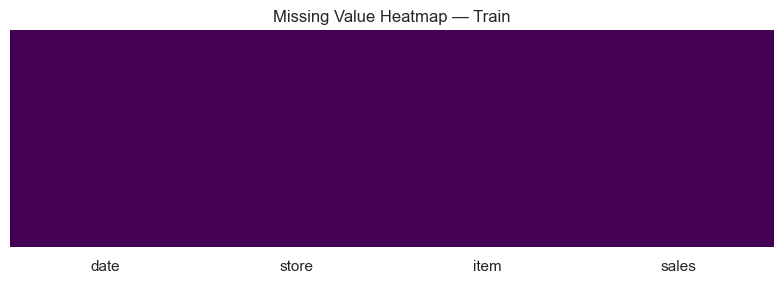

In [12]:
# Visual heatmap
plt.figure(figsize=(8, 3))
sns.heatmap(train.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Value Heatmap — Train")
plt.tight_layout()
plt.show()

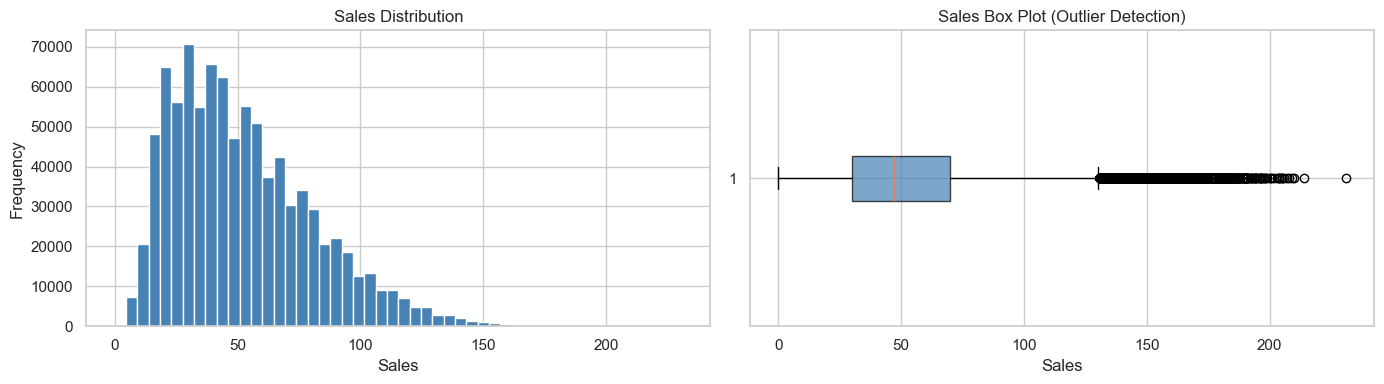

Skewness: 0.867
Kurtosis: 0.509


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
 
# Histogram
axes[0].hist(train["sales"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Sales Distribution")
axes[0].set_xlabel("Sales")
axes[0].set_ylabel("Frequency")
 
# Box plot
axes[1].boxplot(train["sales"], vert=False, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.7))
axes[1].set_title("Sales Box Plot (Outlier Detection)")
axes[1].set_xlabel("Sales")
 
plt.tight_layout()
plt.show()
 
print("Skewness:", round(train["sales"].skew(), 3))
print("Kurtosis:", round(train["sales"].kurt(), 3))

In [14]:
# Outlier analysis (IQR method)
Q1 = train["sales"].quantile(0.25)
Q3 = train["sales"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
 
outliers = train[(train["sales"] < lower) | (train["sales"] > upper)]
print(f"Lower bound : {lower:.2f}")
print(f"Upper bound : {upper:.2f}")
print(f"Outlier rows: {len(outliers)} ({len(outliers)/len(train)*100:.2f}%)")

Lower bound : -30.00
Upper bound : 130.00
Outlier rows: 11967 (1.31%)


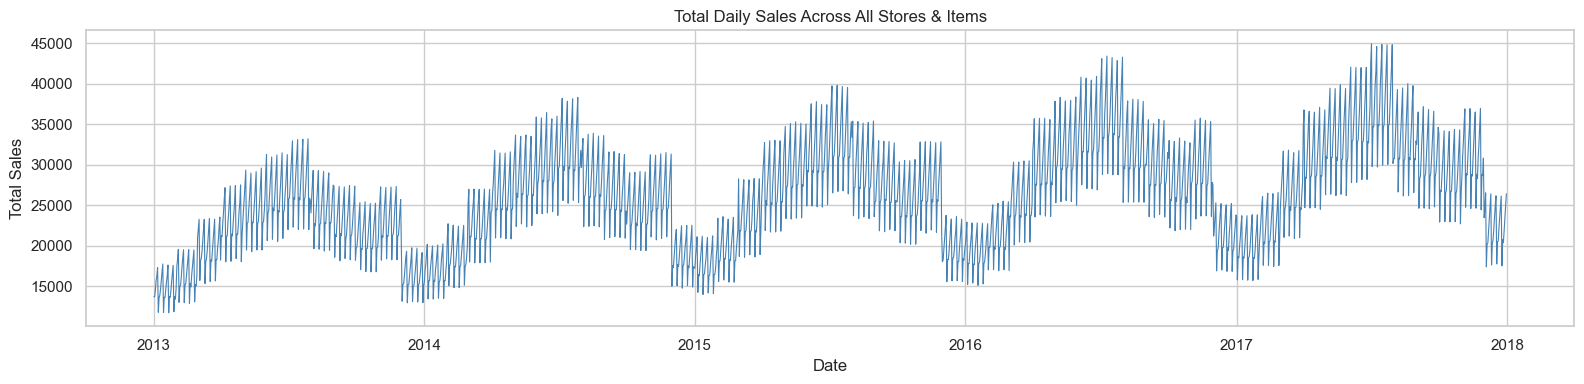

In [15]:
# Overall Sales Over Time
daily_sales = train.groupby("date")["sales"].sum().reset_index()
 
plt.figure(figsize=(16, 4))
plt.plot(daily_sales["date"], daily_sales["sales"], linewidth=0.8, color="steelblue")
plt.title("Total Daily Sales Across All Stores & Items")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

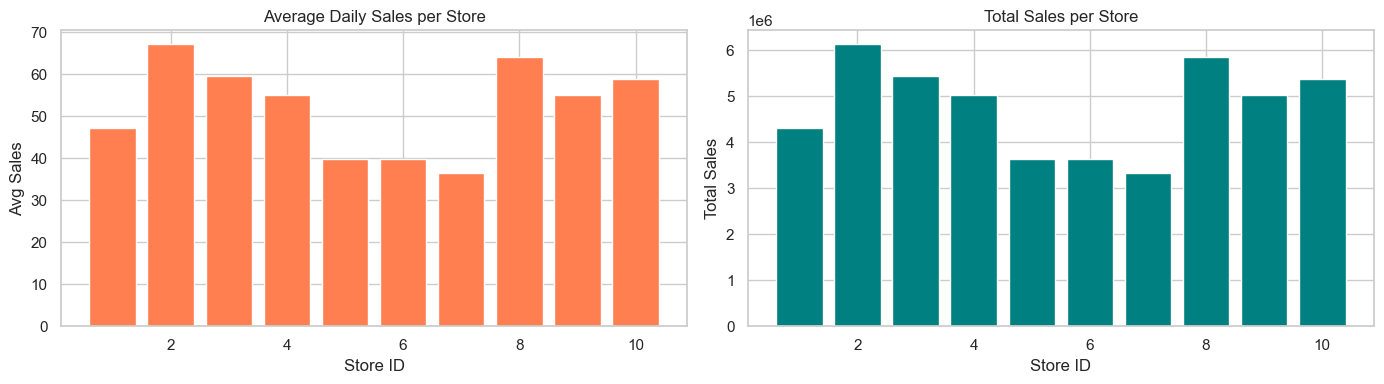

In [16]:
# Store level EDA
store_sales = train.groupby("store")["sales"].agg(["mean", "sum", "std"]).reset_index()
store_sales.columns = ["store", "avg_sales", "total_sales", "std_sales"]
 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
 
axes[0].bar(store_sales["store"], store_sales["avg_sales"], color="coral")
axes[0].set_title("Average Daily Sales per Store")
axes[0].set_xlabel("Store ID")
axes[0].set_ylabel("Avg Sales")
 
axes[1].bar(store_sales["store"], store_sales["total_sales"], color="teal")
axes[1].set_title("Total Sales per Store")
axes[1].set_xlabel("Store ID")
axes[1].set_ylabel("Total Sales")
 
plt.tight_layout()
plt.show()

In [17]:
print(store_sales.sort_values("total_sales", ascending=False))

   store  avg_sales  total_sales  std_sales
1      2  67.033165      6120128  33.595810
7      8  64.142048      5856169  32.231751
2      3  59.530602      5435144  29.974102
9     10  58.709288      5360158  29.554994
8      9  55.049025      5025976  27.832186
3      4  54.902946      5012639  27.733097
0      1  47.268379      4315603  24.006252
4      5  39.770164      3631016  20.365757
5      6  39.733516      3627670  20.310451
6      7  36.363735      3320009  18.684825


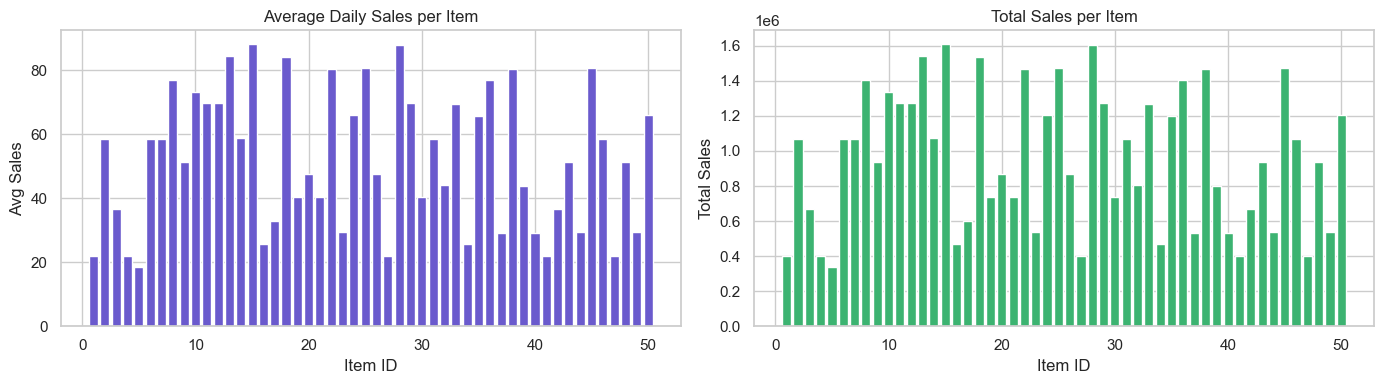

In [18]:
# Item Level EDA
item_sales = train.groupby("item")["sales"].agg(["mean", "sum"]).reset_index()
item_sales.columns = ["item", "avg_sales", "total_sales"]
 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
 
axes[0].bar(item_sales["item"], item_sales["avg_sales"], color="slateblue")
axes[0].set_title("Average Daily Sales per Item")
axes[0].set_xlabel("Item ID")
axes[0].set_ylabel("Avg Sales")
 
axes[1].bar(item_sales["item"], item_sales["total_sales"], color="mediumseagreen")
axes[1].set_title("Total Sales per Item")
axes[1].set_xlabel("Item ID")
axes[1].set_ylabel("Total Sales")
 
plt.tight_layout()
plt.show()

In [19]:
# Top 5 and bottom 5 items
print("Top 5 items by total sales:")
print(item_sales.sort_values("total_sales", ascending=False).head())
print("\nBottom 5 items by total sales:")
print(item_sales.sort_values("total_sales").head())

Top 5 items by total sales:
    item  avg_sales  total_sales
14    15  88.030778      1607442
27    28  87.881325      1604713
12    13  84.316594      1539621
17    18  84.275794      1538876
24    25  80.686418      1473334

Bottom 5 items by total sales:
    item  avg_sales  total_sales
4      5  18.358708       335230
0      1  21.981599       401384
40    41  22.002136       401759
46    47  22.003341       401781
3      4  22.010241       401907


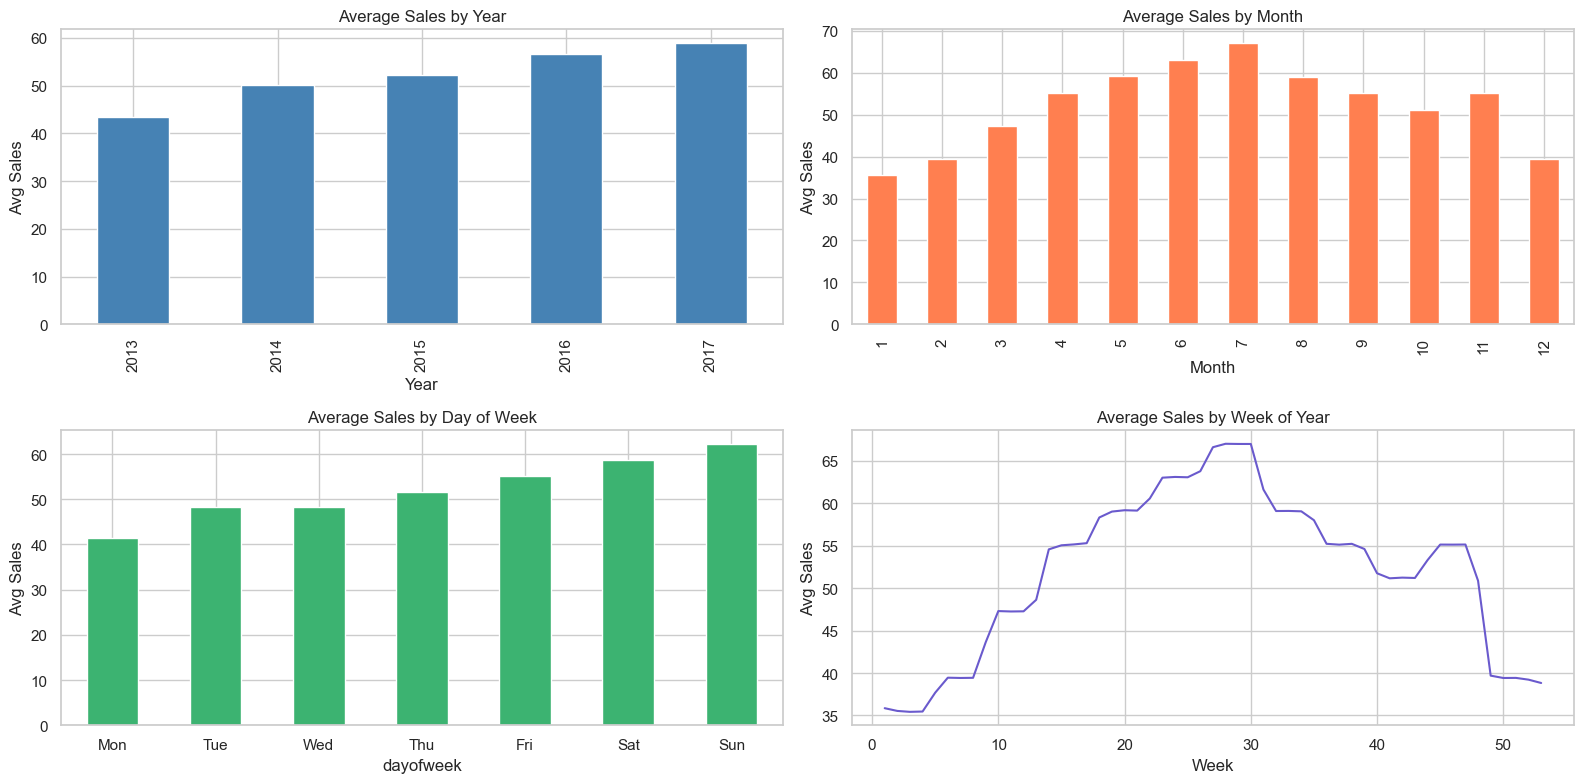

In [20]:
# Yearly, Monthly, Weekly Sales Patterns
train["year"]  = train["date"].dt.year
train["month"] = train["date"].dt.month
train["week"]  = train["date"].dt.isocalendar().week.astype(int)
train["dayofweek"] = train["date"].dt.dayofweek
 
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
 
# By year
train.groupby("year")["sales"].mean().plot(ax=axes[0,0], kind="bar", color="steelblue")
axes[0,0].set_title("Average Sales by Year")
axes[0,0].set_xlabel("Year"); axes[0,0].set_ylabel("Avg Sales")
 
# By month
train.groupby("month")["sales"].mean().plot(ax=axes[0,1], kind="bar", color="coral")
axes[0,1].set_title("Average Sales by Month")
axes[0,1].set_xlabel("Month"); axes[0,1].set_ylabel("Avg Sales")
 
# By day of week
day_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
train.groupby("dayofweek")["sales"].mean().plot(ax=axes[1,0], kind="bar", color="mediumseagreen")
axes[1,0].set_title("Average Sales by Day of Week")
axes[1,0].set_xticklabels(day_labels, rotation=0)
axes[1,0].set_ylabel("Avg Sales")
 
# By week
train.groupby("week")["sales"].mean().plot(ax=axes[1,1], color="slateblue")
axes[1,1].set_title("Average Sales by Week of Year")
axes[1,1].set_xlabel("Week"); axes[1,1].set_ylabel("Avg Sales")
 
plt.tight_layout()
plt.show()

In [21]:
# Time Series Decomposition (one store-item pair)

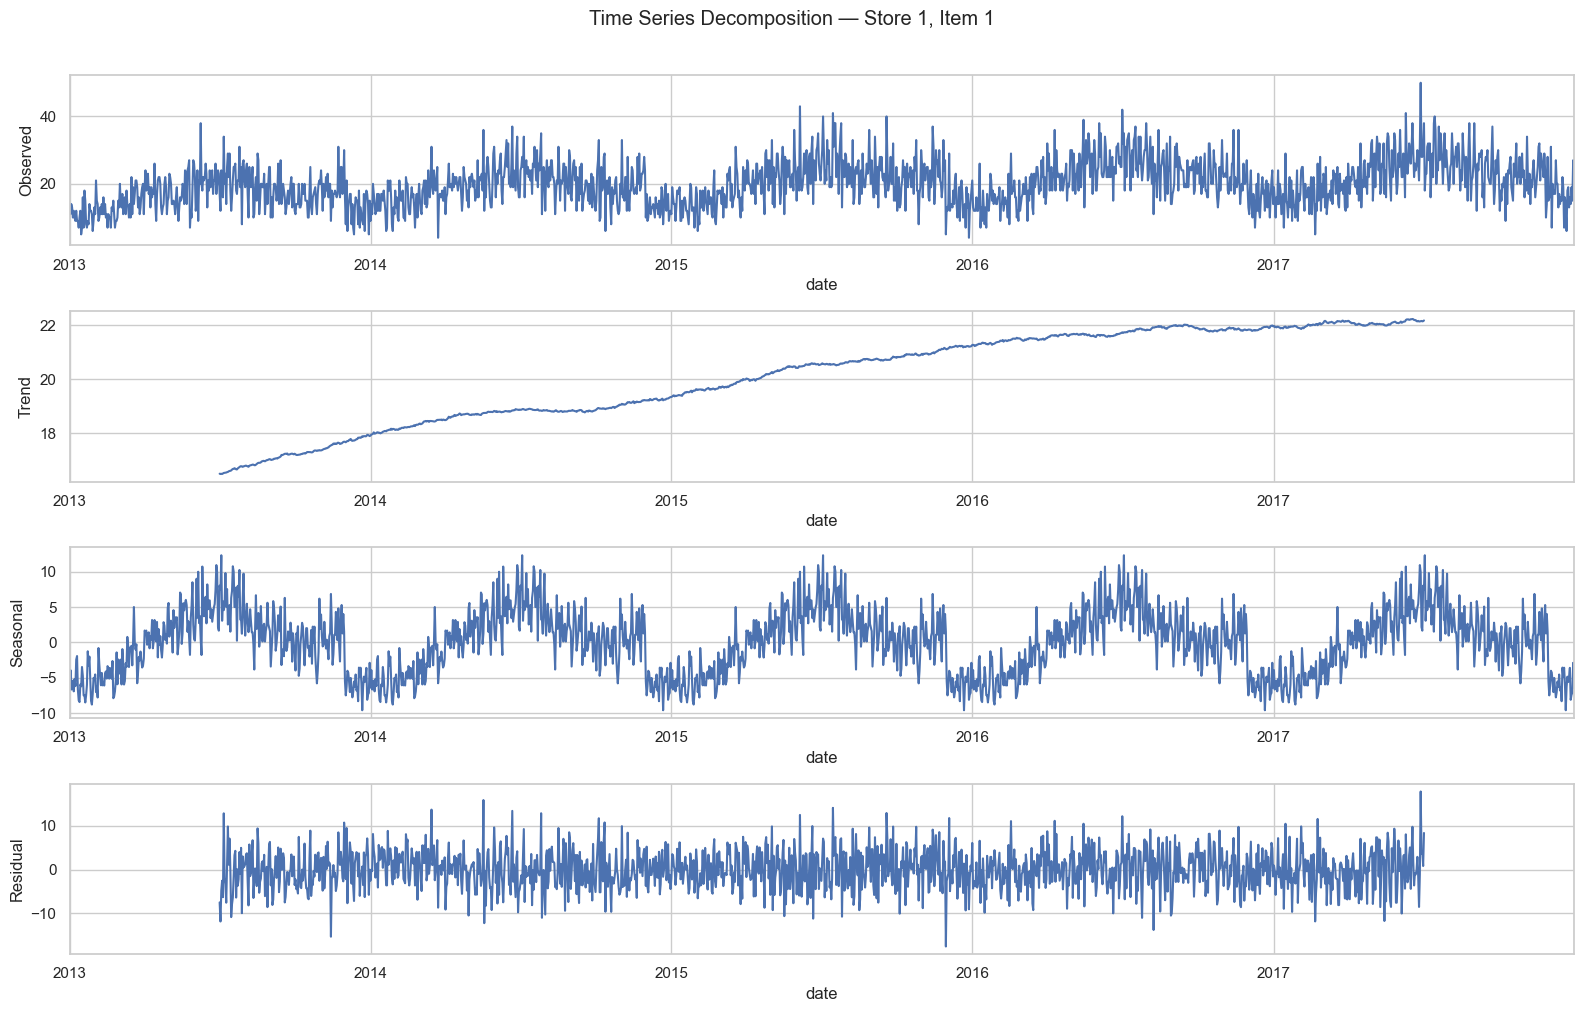

In [22]:
from statsmodels.tsa.seasonal import seasonal_decompose
 
# Pick store 1, item 1 for illustration
s1i1 = train[(train["store"] == 1) & (train["item"] == 1)].set_index("date")["sales"]
s1i1 = s1i1.asfreq("D")  # daily frequency
 
decomposition = seasonal_decompose(s1i1, model="additive", period=365)
 
fig, axes = plt.subplots(4, 1, figsize=(16, 10))
decomposition.observed.plot(ax=axes[0]); axes[0].set_ylabel("Observed")
decomposition.trend.plot(ax=axes[1]);    axes[1].set_ylabel("Trend")
decomposition.seasonal.plot(ax=axes[2]); axes[2].set_ylabel("Seasonal")
decomposition.resid.plot(ax=axes[3]);    axes[3].set_ylabel("Residual")
plt.suptitle("Time Series Decomposition — Store 1, Item 1", y=1.01)
plt.tight_layout()
plt.show()

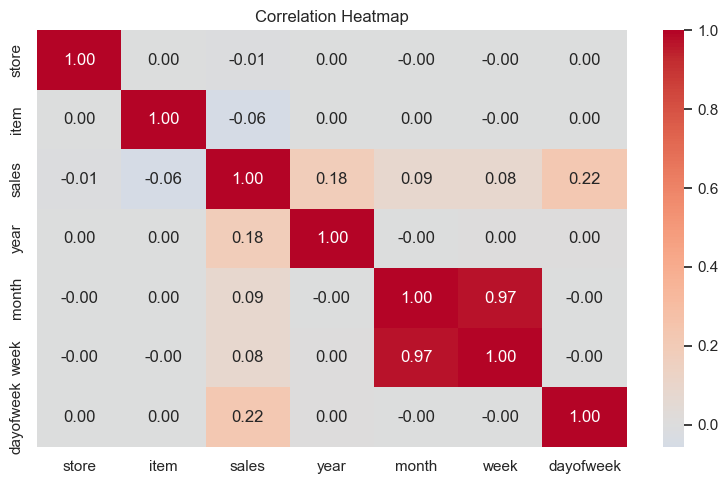

In [23]:
# Correlation heatmap
corr_df = train[["store", "item", "sales", "year", "month", "week", "dayofweek"]]
plt.figure(figsize=(8, 5))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [24]:
# Time Series Feature Engineering
def create_features(df):
    """
    Create all temporal and demand features.
    Works on both train and test DataFrames.
    """
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["store", "item", "date"]).reset_index(drop=True)
 
    # Calendar features 
    df["year"]        = df["date"].dt.year
    df["month"]       = df["date"].dt.month
    df["day"]         = df["date"].dt.day
    df["dayofweek"]   = df["date"].dt.dayofweek          # 0=Monday
    df["dayofyear"]   = df["date"].dt.dayofyear
    df["weekofyear"]  = df["date"].dt.isocalendar().week.astype(int)
    df["quarter"]     = df["date"].dt.quarter
    df["is_weekend"]  = (df["dayofweek"] >= 5).astype(int)
    df["is_month_start"] = df["date"].dt.is_month_start.astype(int)
    df["is_month_end"]   = df["date"].dt.is_month_end.astype(int)
 
    # Cyclical encoding (sin/cos) — removes discontinuity at boundaries
    df["month_sin"]      = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"]      = np.cos(2 * np.pi * df["month"] / 12)
    df["dayofweek_sin"]  = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dayofweek_cos"]  = np.cos(2 * np.pi * df["dayofweek"] / 7)
    df["dayofyear_sin"]  = np.sin(2 * np.pi * df["dayofyear"] / 365)
    df["dayofyear_cos"]  = np.cos(2 * np.pi * df["dayofyear"] / 365)
 
    # Lag features (only possible for train; filled NaN for test) 
    # Group by store+item so lags don't bleed across series
    grp = df.groupby(["store", "item"])["sales"] if "sales" in df.columns else None
 
    if grp is not None:
        for lag in [7, 14, 21, 28, 90, 180, 365]:
            df[f"lag_{lag}"] = grp.shift(lag)
 
        # Rolling statistics 
        for window in [7, 14, 30, 90]:
            df[f"rolling_mean_{window}"] = grp.transform(
                lambda x: x.shift(1).rolling(window, min_periods=1).mean()
            )
            df[f"rolling_std_{window}"]  = grp.transform(
                lambda x: x.shift(1).rolling(window, min_periods=1).std()
            )
            df[f"rolling_max_{window}"]  = grp.transform(
                lambda x: x.shift(1).rolling(window, min_periods=1).max()
            )
            df[f"rolling_min_{window}"]  = grp.transform(
                lambda x: x.shift(1).rolling(window, min_periods=1).min()
            )
 
        # Expanding (cumulative) features
        df["expanding_mean"] = grp.transform(
            lambda x: x.shift(1).expanding().mean()
        )
 
        # Trend / diff features 
        df["sales_diff_1"]  = grp.diff(1)
        df["sales_diff_7"]  = grp.diff(7)
 
    return df

In [25]:
# Apply feature engineering
print("Creating features for training set...")
train_fe = create_features(train)

Creating features for training set...


In [26]:
# Test has no sales column — we'll fill NaN lag features later
# For test, merge in last-known stats from train tail
print("Creating features for test set...")
# Append test to train (sales=NaN for test), compute features, then split
train_copy = train.copy()
test_copy  = test.copy()
test_copy["sales"] = np.nan
 
combined = pd.concat([train_copy, test_copy], axis=0, ignore_index=True)
combined_fe = create_features(combined)
 
test_fe  = combined_fe[combined_fe["sales"].isna()].copy()
train_fe = combined_fe[combined_fe["sales"].notna()].copy()
 
print("Train feature set shape:", train_fe.shape)
print("Test  feature set shape:", test_fe.shape)
print("\nSample feature columns:", train_fe.columns.tolist())

Creating features for test set...
Train feature set shape: (913000, 48)
Test  feature set shape: (45000, 48)

Sample feature columns: ['date', 'store', 'item', 'sales', 'year', 'month', 'week', 'dayofweek', 'id', 'day', 'dayofyear', 'weekofyear', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'month_sin', 'month_cos', 'dayofweek_sin', 'dayofweek_cos', 'dayofyear_sin', 'dayofyear_cos', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_90', 'lag_180', 'lag_365', 'rolling_mean_7', 'rolling_std_7', 'rolling_max_7', 'rolling_min_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_max_14', 'rolling_min_14', 'rolling_mean_30', 'rolling_std_30', 'rolling_max_30', 'rolling_min_30', 'rolling_mean_90', 'rolling_std_90', 'rolling_max_90', 'rolling_min_90', 'expanding_mean', 'sales_diff_1', 'sales_diff_7']


In [27]:

#  Feature List & Target

# Drop raw date and target from features
FEATURE_COLS = [c for c in train_fe.columns
                if c not in ["date", "sales", "id"]]
 
TARGET = "sales"
 
print(f"Number of features: {len(FEATURE_COLS)}")
print("Features:", FEATURE_COLS)
 
# Drop rows where lag features are NaN (first ~365 rows per series)
train_clean = train_fe.dropna(subset=["lag_365"]).reset_index(drop=True)
print(f"\nTraining rows after dropping lag-NaN rows: {len(train_clean)}")
 
X = train_clean[FEATURE_COLS]
y = train_clean[TARGET]

Number of features: 45
Features: ['store', 'item', 'year', 'month', 'week', 'dayofweek', 'day', 'dayofyear', 'weekofyear', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'month_sin', 'month_cos', 'dayofweek_sin', 'dayofweek_cos', 'dayofyear_sin', 'dayofyear_cos', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_90', 'lag_180', 'lag_365', 'rolling_mean_7', 'rolling_std_7', 'rolling_max_7', 'rolling_min_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_max_14', 'rolling_min_14', 'rolling_mean_30', 'rolling_std_30', 'rolling_max_30', 'rolling_min_30', 'rolling_mean_90', 'rolling_std_90', 'rolling_max_90', 'rolling_min_90', 'expanding_mean', 'sales_diff_1', 'sales_diff_7']

Training rows after dropping lag-NaN rows: 730500


In [28]:
# Train / Validation Split (time-based — no data leakage)

# Use last 3 months of training data as validation
split_date = pd.Timestamp("2017-10-01")
 
train_mask = train_clean["date"] < split_date
val_mask   = train_clean["date"] >= split_date
 
X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
 
print(f"Train period : {train_clean.loc[train_mask, 'date'].min().date()} → {train_clean.loc[train_mask, 'date'].max().date()}")
print(f"Val   period : {train_clean.loc[val_mask,   'date'].min().date()} → {train_clean.loc[val_mask,   'date'].max().date()}")
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")

Train period : 2014-01-01 → 2017-09-30
Val   period : 2017-10-01 → 2017-12-31
X_train: (684500, 45), X_val: (46000, 45)


In [29]:
# Evaluation Helper Function
def evaluate(model_name, y_true, y_pred):
    """Print and return MAE, RMSE, R2."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    smape = np.mean(
        200 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true) + 1e-8)
    )
    print(f"\n{'='*40}")
    print(f"Model   : {model_name}")
    print(f"MAE     : {mae:.4f}")
    print(f"RMSE    : {rmse:.4f}")
    print(f"SMAPE   : {smape:.2f}%")
    print(f"R²      : {r2:.4f}")
    print(f"{'='*40}")
    return {"Model": model_name, "MAE": round(mae,4),
            "RMSE": round(rmse,4), "SMAPE": round(smape,2), "R2": round(r2,4)}

In [30]:
def plot_predictions(y_true, y_pred, model_name, n=200):
    """Plot actual vs predicted for first n samples."""
    plt.figure(figsize=(14, 4))
    plt.plot(y_true.values[:n], label="Actual", color="steelblue")
    plt.plot(y_pred[:n],        label="Predicted", color="coral", alpha=0.8)
    plt.title(f"Actual vs Predicted — {model_name} (first {n} samples)")
    plt.legend()
    plt.tight_layout()
    plt.show()
 
 
results = []    # collect all model results here
os.makedirs("saved_models", exist_ok=True)

In [31]:
# MLflow Setup
mlflow.set_experiment("Retail_Demand_Forecasting")
print("MLflow experiment set: Retail_Demand_Forecasting")

2026/06/03 07:14:20 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/03 07:14:20 INFO mlflow.store.db.utils: Updating database tables
2026/06/03 07:14:20 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/06/03 07:14:20 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/06/03 07:14:21 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/06/03 07:14:21 INFO alembic.runtime.migration: Will assume non-transactional DDL.


MLflow experiment set: Retail_Demand_Forecasting



Model   : Linear Regression
MAE     : 0.0000
RMSE    : 0.0000
SMAPE   : 0.00%
R²      : 1.0000


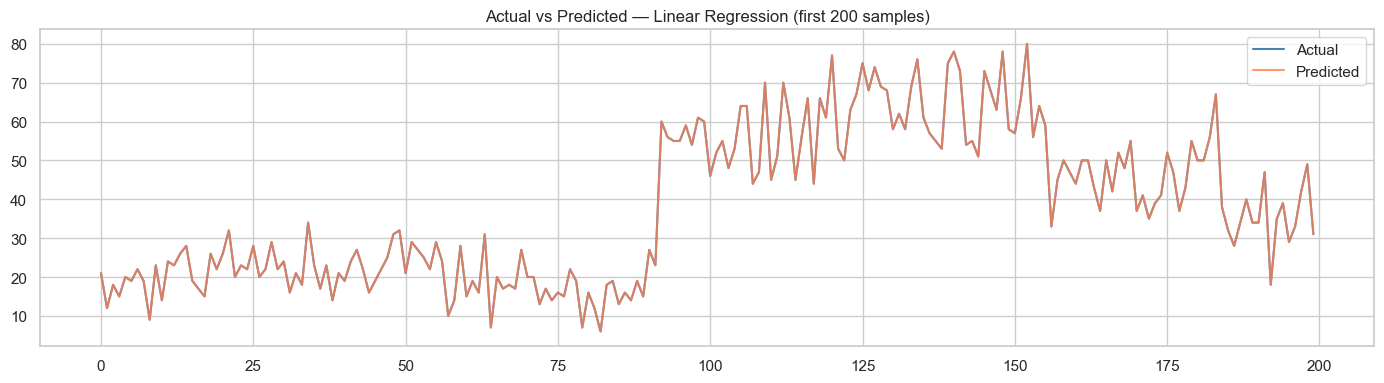

2026/06/03 07:14:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Linear Regression saved


In [32]:
# MODEL 1: Linear Regression
with mlflow.start_run(run_name="LinearRegression"):
 
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    preds_lr = lr.predict(X_val)
    preds_lr = np.clip(preds_lr, 0, None)   # sales can't be negative
 
    metrics = evaluate("Linear Regression", y_val, preds_lr)
    results.append(metrics)
    plot_predictions(y_val, preds_lr, "Linear Regression")
 
    mlflow.log_metrics({k: v for k, v in metrics.items() if k != "Model"})
    mlflow.sklearn.log_model(lr, "model")
 
    joblib.dump(lr, "saved_models/linear_regression.pkl")
    print("Linear Regression saved")


Model   : Random Forest
MAE     : 0.7668
RMSE    : 1.1638
SMAPE   : 2.28%
R²      : 0.9983


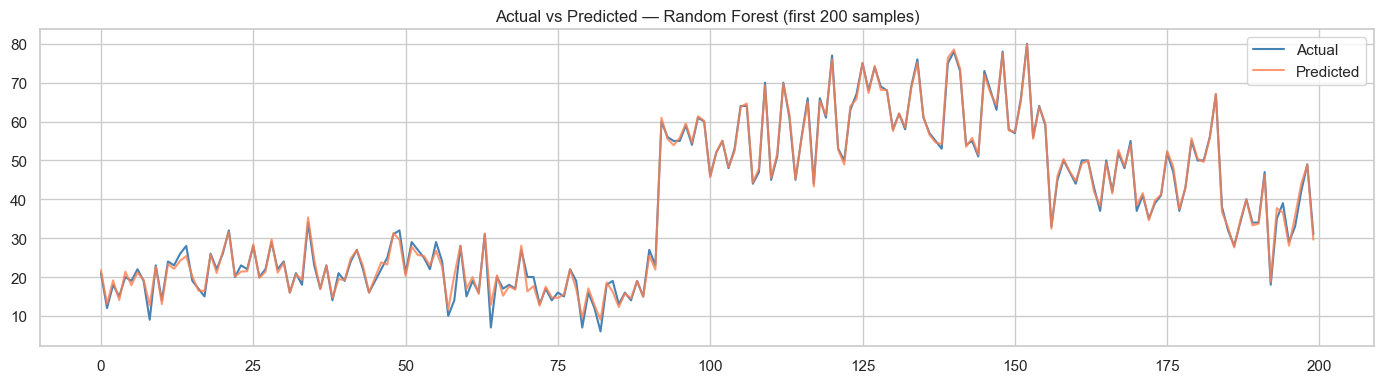

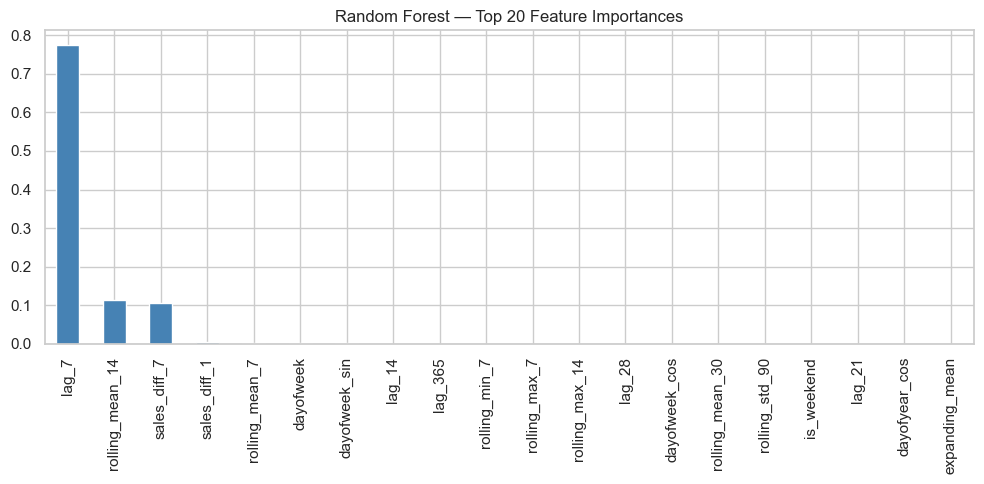

2026/06/03 07:17:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


 Random Forest saved


In [33]:
# MODEL 2: Random Forest
with mlflow.start_run(run_name="RandomForest"):
 
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42
    )
    rf.fit(X_train, y_train)
    preds_rf = rf.predict(X_val)
    preds_rf = np.clip(preds_rf, 0, None)
 
    metrics = evaluate("Random Forest", y_val, preds_rf)
    results.append(metrics)
    plot_predictions(y_val, preds_rf, "Random Forest")
 
    # Feature importance
    feat_imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS)
    plt.figure(figsize=(10, 5))
    feat_imp.sort_values(ascending=False).head(20).plot(kind="bar", color="steelblue")
    plt.title("Random Forest — Top 20 Feature Importances")
    plt.tight_layout()
    plt.show()
 
    mlflow.log_metrics({k: v for k, v in metrics.items() if k != "Model"})
    mlflow.sklearn.log_model(rf, "model")
 
    joblib.dump(rf, "saved_models/random_forest.pkl")
    print(" Random Forest saved")


Model   : AdaBoost
MAE     : 6.2556
RMSE    : 8.0948
SMAPE   : 14.55%
R²      : 0.9192


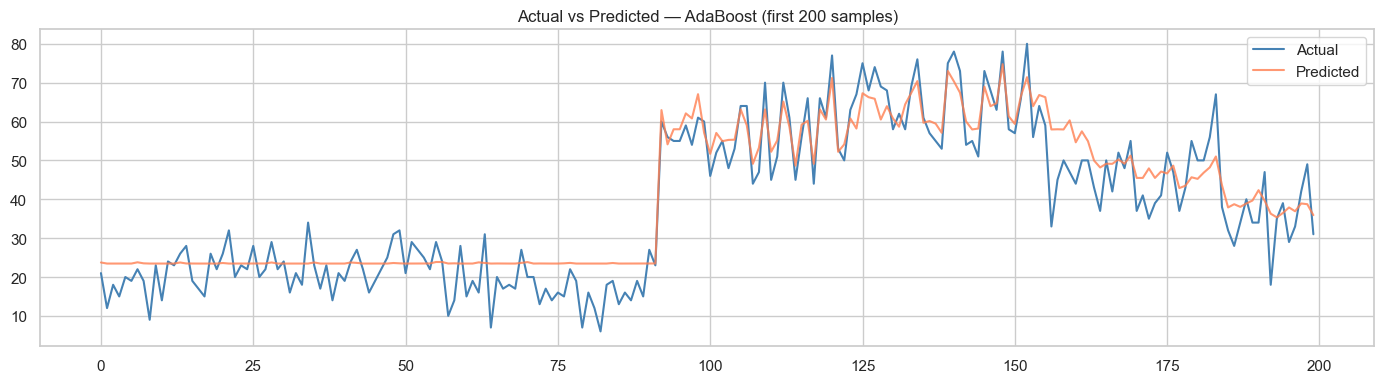

2026/06/03 07:40:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


 AdaBoost saved


In [34]:
# Model 3: AdaBoost
with mlflow.start_run(run_name="AdaBoost"):
 
    ada = AdaBoostRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )
    ada.fit(X_train, y_train)
    preds_ada = ada.predict(X_val)
    preds_ada = np.clip(preds_ada, 0, None)
 
    metrics = evaluate("AdaBoost", y_val, preds_ada)
    results.append(metrics)
    plot_predictions(y_val, preds_ada, "AdaBoost")
 
    mlflow.log_metrics({k: v for k, v in metrics.items() if k != "Model"})
    mlflow.sklearn.log_model(ada, "model")
 
    joblib.dump(ada, "saved_models/adaboost.pkl")
    print(" AdaBoost saved")


Model   : HistGradientBoosting
MAE     : 0.4685
RMSE    : 0.6471
SMAPE   : 1.24%
R²      : 0.9995


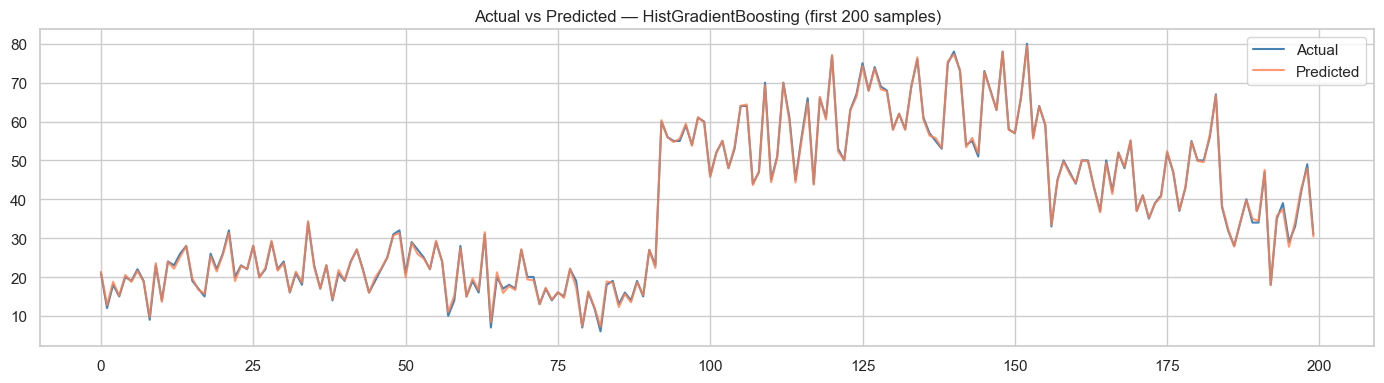

2026/06/03 08:25:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


HistGradientBoosting saved


In [36]:
from sklearn.ensemble import HistGradientBoostingRegressor
import joblib
import mlflow
import numpy as np

# MODEL 4: HistGradientBoosting
with mlflow.start_run(run_name="HistGradientBoosting"):

    hgb = HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=5,
        max_iter=200,
        min_samples_leaf=5,
        random_state=42
    )

    hgb.fit(X_train, y_train)

    preds_hgb = hgb.predict(X_val)
    preds_hgb = np.clip(preds_hgb, 0, None)

    metrics = evaluate("HistGradientBoosting", y_val, preds_hgb)
    results.append(metrics)

    plot_predictions(y_val, preds_hgb, "HistGradientBoosting")

    # Log metrics to MLflow
    mlflow.log_metrics(
        {k: v for k, v in metrics.items() if k != "Model"}
    )

    # Log model
    mlflow.sklearn.log_model(hgb, "model")

    # Save model locally
    joblib.dump(
        hgb,
        "saved_models/hist_gradient_boosting.pkl"
    )

    print("HistGradientBoosting saved")

[0]	validation_0-rmse:27.10587
[50]	validation_0-rmse:2.95968
[100]	validation_0-rmse:1.31512
[150]	validation_0-rmse:1.08131
[200]	validation_0-rmse:0.94709
[250]	validation_0-rmse:0.84572
[299]	validation_0-rmse:0.77454

Model   : XGBoost
MAE     : 0.5879
RMSE    : 0.7745
SMAPE   : 1.39%
R²      : 0.9993


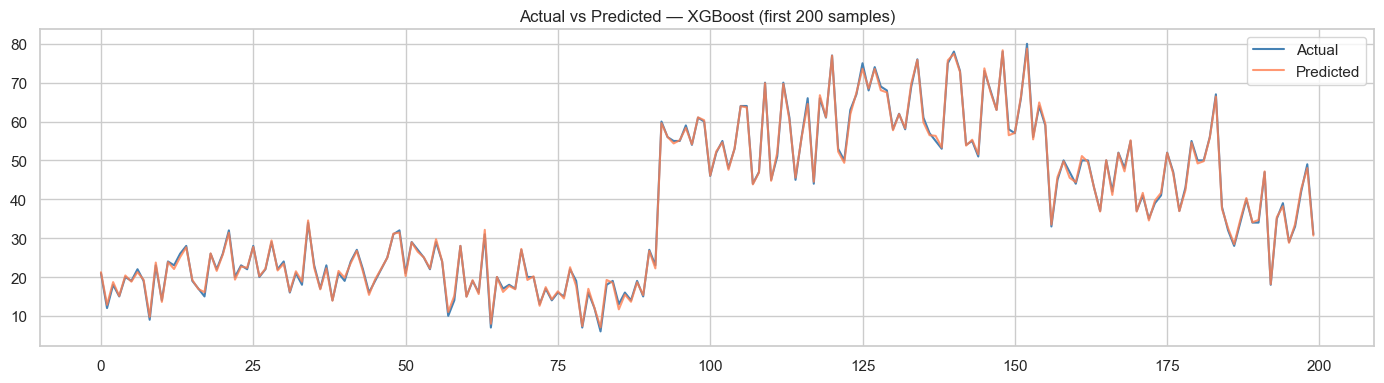

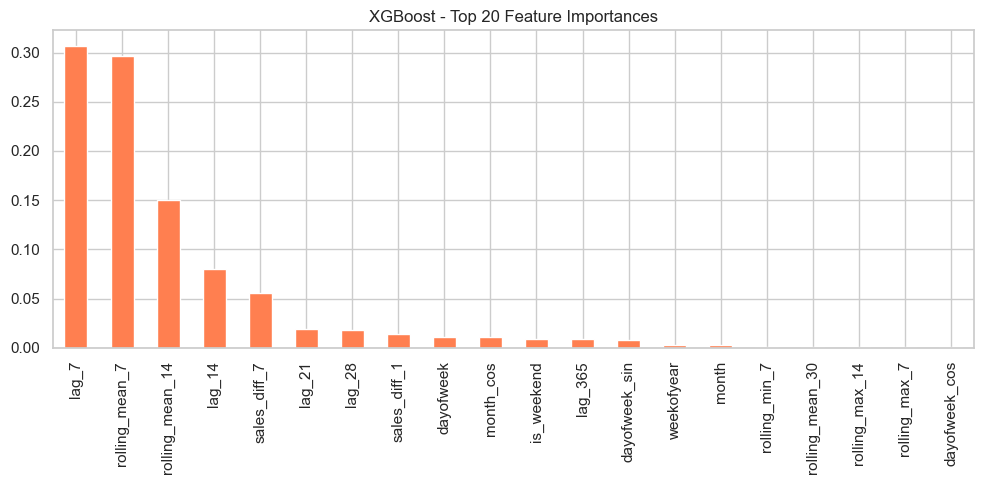

 XGBoost saved


In [37]:
# MODEL 5: XGBoost
with mlflow.start_run(run_name="XGBoost"):
 
    xgb = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    xgb.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=50
    )
    preds_xgb = xgb.predict(X_val)
    preds_xgb = np.clip(preds_xgb, 0, None)
 
    metrics = evaluate("XGBoost", y_val, preds_xgb)
    results.append(metrics)
    plot_predictions(y_val, preds_xgb, "XGBoost")
 
    # Feature importance
    feat_imp = pd.Series(xgb.feature_importances_, index=FEATURE_COLS)
    plt.figure(figsize=(10, 5))
    feat_imp.sort_values(ascending=False).head(20).plot(kind="bar", color="coral")
    plt.title("XGBoost - Top 20 Feature Importances")
    plt.tight_layout()
    plt.show()
 
    mlflow.log_metrics({k: v for k, v in metrics.items() if k != "Model"})
    xgb.save_model("saved_models/xgboost_model.json")
    print(" XGBoost saved")

[100]	valid_0's l2: 5.09629
[200]	valid_0's l2: 1.24198
[300]	valid_0's l2: 0.755018
[400]	valid_0's l2: 0.532879
[500]	valid_0's l2: 0.405471

Model   : LightGBM
MAE     : 0.4665
RMSE    : 0.6368
SMAPE   : 1.10%
R²      : 0.9995


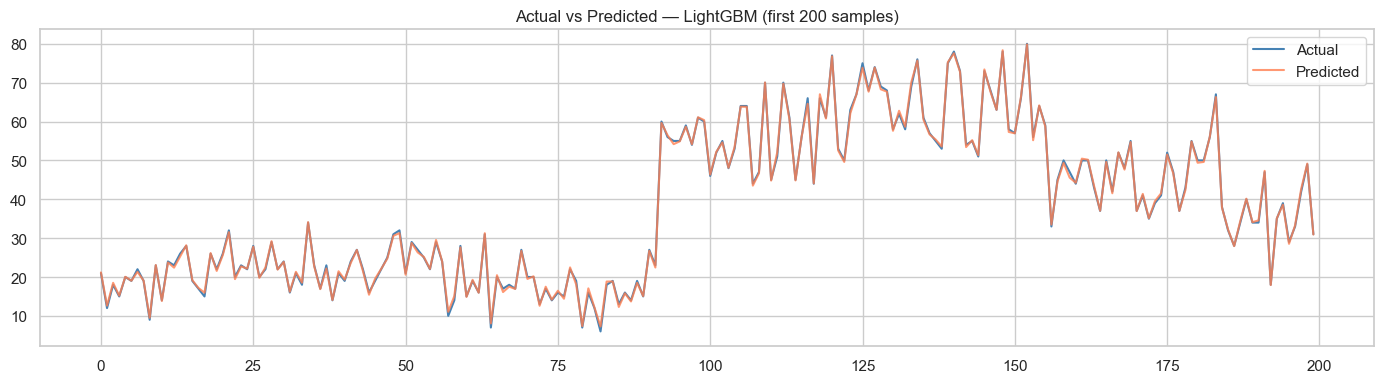

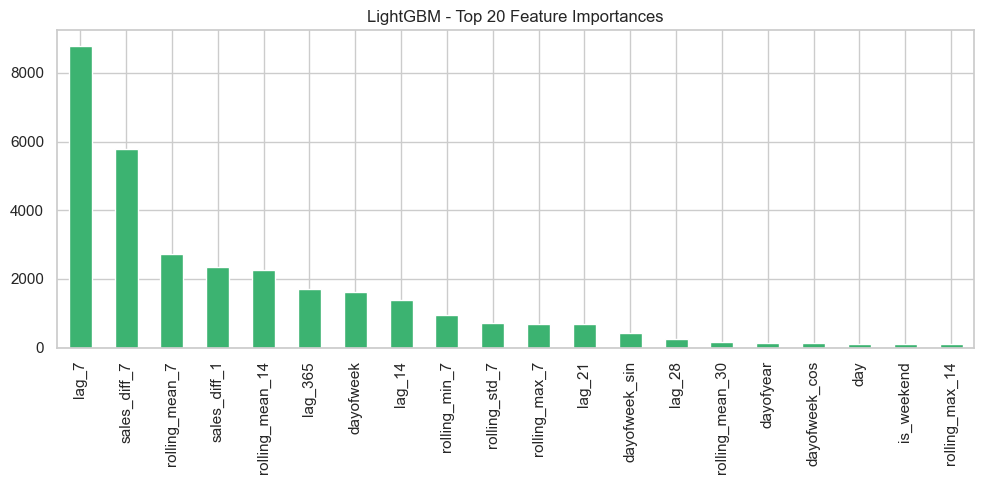

2026/06/03 08:26:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


LightGBM saved


In [38]:
# MODEL 6: LightGBM
with mlflow.start_run(run_name="LightGBM"):
 
    lgb = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=64,
        max_depth=-1,
        min_child_samples=20,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=5,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    lgb.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            __import__("lightgbm").early_stopping(50, verbose=False),
            __import__("lightgbm").log_evaluation(100)
        ]
    )
    preds_lgb = lgb.predict(X_val)
    preds_lgb = np.clip(preds_lgb, 0, None)
 
    metrics = evaluate("LightGBM", y_val, preds_lgb)
    results.append(metrics)
    plot_predictions(y_val, preds_lgb, "LightGBM")
 
    # Feature importance
    feat_imp = pd.Series(lgb.feature_importances_, index=FEATURE_COLS)
    plt.figure(figsize=(10, 5))
    feat_imp.sort_values(ascending=False).head(20).plot(kind="bar", color="mediumseagreen")
    plt.title("LightGBM - Top 20 Feature Importances")
    plt.tight_layout()
    plt.show()
 
    mlflow.log_metrics({k: v for k, v in metrics.items() if k != "Model"})
    mlflow.sklearn.log_model(lgb, "model")
 
    joblib.dump(lgb, "saved_models/lightgbm.pkl")
    print("LightGBM saved")

0:	learn: 28.8394426	test: 27.7157518	best: 27.7157518 (0)	total: 264ms	remaining: 2m 11s
100:	learn: 3.1731041	test: 3.2685196	best: 3.2685196 (100)	total: 6.01s	remaining: 23.8s
200:	learn: 1.4077877	test: 1.5245378	best: 1.5245378 (200)	total: 11.2s	remaining: 16.7s
300:	learn: 1.0317124	test: 1.0853030	best: 1.0853030 (300)	total: 16s	remaining: 10.6s
400:	learn: 0.8150879	test: 0.8530902	best: 0.8530902 (400)	total: 21.1s	remaining: 5.2s
499:	learn: 0.6919198	test: 0.7240340	best: 0.7240340 (499)	total: 25.9s	remaining: 0us

bestTest = 0.7240340424
bestIteration = 499


Model   : CatBoost
MAE     : 0.5610
RMSE    : 0.7240
SMAPE   : 1.40%
R²      : 0.9994


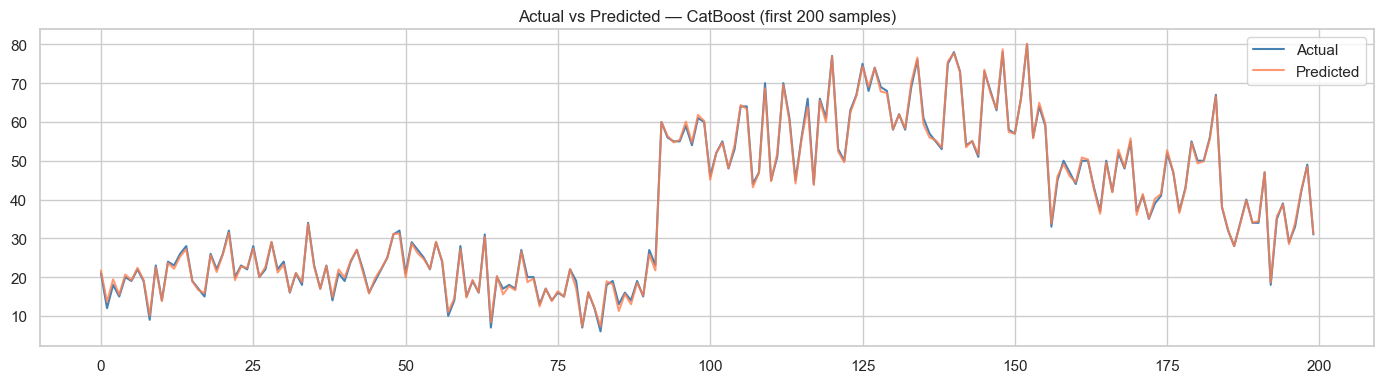

 CatBoost saved


In [39]:
# MODEL 7: CatBoost
with mlflow.start_run(run_name="CatBoost"):
 
    cat = CatBoostRegressor(
        iterations=500,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=3,
        random_seed=42,
        verbose=100
    )
    cat.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=50
    )
    preds_cat = cat.predict(X_val)
    preds_cat = np.clip(preds_cat, 0, None)
 
    metrics = evaluate("CatBoost", y_val, preds_cat)
    results.append(metrics)
    plot_predictions(y_val, preds_cat, "CatBoost")
 
    mlflow.log_metrics({k: v for k, v in metrics.items() if k != "Model"})
    cat.save_model("saved_models/catboost_model.cbm")
    print(" CatBoost saved")


MODEL COMPARISON — Validation Set
               Model    MAE   RMSE  SMAPE     R2
   Linear Regression 0.0000 0.0000   0.00 1.0000
            LightGBM 0.4665 0.6368   1.10 0.9995
HistGradientBoosting 0.4685 0.6471   1.24 0.9995
            CatBoost 0.5610 0.7240   1.40 0.9994
             XGBoost 0.5879 0.7745   1.39 0.9993
       Random Forest 0.7668 1.1638   2.28 0.9983
            AdaBoost 6.2556 8.0948  14.55 0.9192


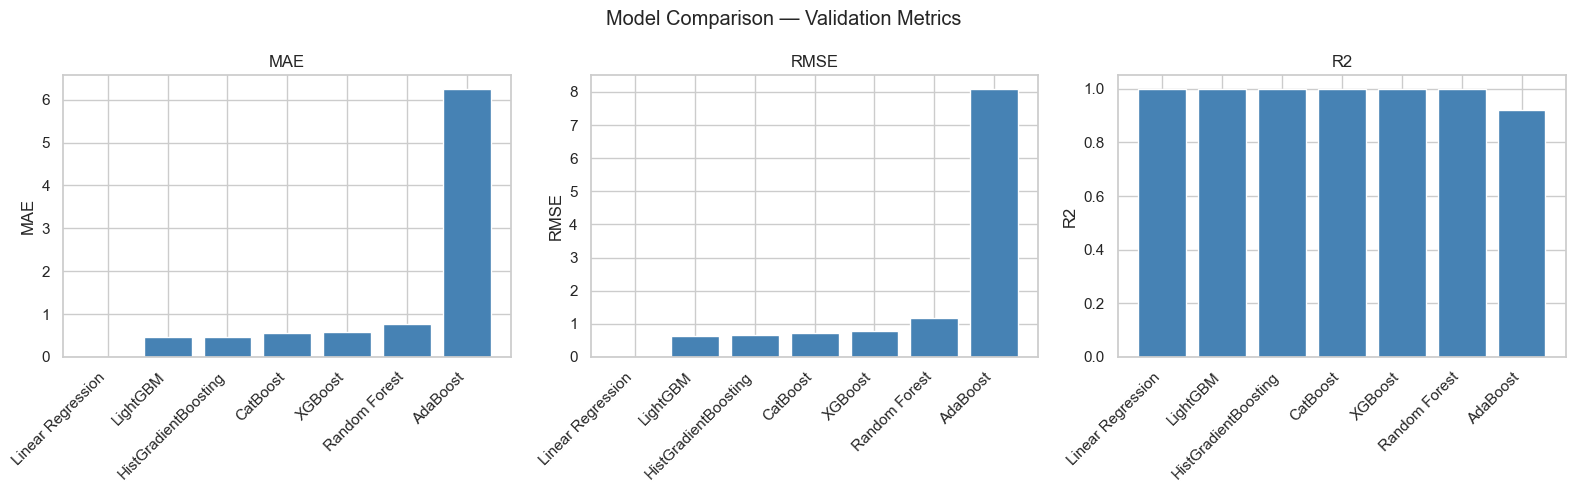

In [40]:
# Model Comparison Table    
results_df = pd.DataFrame(results).sort_values("RMSE")
print("\n" + "=" * 60)
print("MODEL COMPARISON — Validation Set")
print("=" * 60)
print(results_df.to_string(index=False))
 
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
for i, metric in enumerate(["MAE", "RMSE", "R2"]):
    axes[i].bar(results_df["Model"], results_df[metric], color="steelblue")
    axes[i].set_title(metric)
    axes[i].set_xticklabels(results_df["Model"], rotation=45, ha="right")
    axes[i].set_ylabel(metric)
 
plt.suptitle("Model Comparison — Validation Metrics")
plt.tight_layout()
plt.show()

In [41]:
# Best Model Inference on Test Set
# LightGBM is typically best for this kind of tabular time series
best_model = lgb
 
X_test = test_fe[FEATURE_COLS].fillna(0)  # fill any remaining NaN
test_preds = best_model.predict(X_test)
test_preds = np.clip(test_preds, 0, None)
 
# Build submission
submission = test[["id"]].copy()
submission["sales"] = np.round(test_preds).astype(int)
submission.to_csv("submission_lightgbm.csv", index=False)
 
print("Submission saved → submission_lightgbm.csv")
print(submission.head(10))

Submission saved → submission_lightgbm.csv
   id  sales
0   0     13
1   1     16
2   2     15
3   3     19
4   4     16
5   5     26
6   6     23
7   7      6
8   8      7
9   9      7


In [42]:
# Save Feature Column List (needed for API/Streamlit)
import json
with open("saved_models/feature_cols.json", "w") as f:
    json.dump(FEATURE_COLS, f)
 
print("Feature column list saved → saved_models/feature_cols.json")
print("\nNotebook 1 Complete!")
print("Saved models:")
for fname in os.listdir("saved_models"):
    print(" •", fname)

Feature column list saved → saved_models/feature_cols.json

Notebook 1 Complete!
Saved models:
 • adaboost.pkl
 • arima_store1_item1.pkl
 • bilstm_best.keras
 • bilstm_model.keras
 • catboost_model.cbm
 • feature_cols.json
 • gru_best.keras
 • gru_model.keras
 • hist_gradient_boosting.pkl
 • lightgbm.pkl
 • linear_regression.pkl
 • lstm_best.keras
 • lstm_model.keras
 • lstm_scaler.pkl
 • mv_lstm_best.keras
 • mv_lstm_meta.json
 • mv_lstm_model.keras
 • mv_scaler_X.pkl
 • mv_scaler_y.pkl
 • prophet_store1_item1.pkl
 • random_forest.pkl
 • sarimax_store1_item1.pkl
 • sarima_store1_item1.pkl
 • xgboost_model.json
